# Principal Component Analysis (PCA) - Clustering Comparison

This notebook solves two problem statements:

1. **Problem Statement 1**: Compare Hierarchical Clustering and K-Means Clustering on the original dataset vs PCA-transformed dataset (first 3 principal components).
2. **Problem Statement 2**: Apply the same framework to a pharmaceutical heart disease dataset, analyze patient segments, and provide improvement suggestions.

The workflow for each problem:
- Data loading and preprocessing
- K-Means cluster selection using Elbow (Scree) + Silhouette
- Hierarchical and K-Means clustering on original features
- PCA extraction (first 3 PCs), transformed dataset creation
- Hierarchical and K-Means clustering on PCA features
- Before vs after PCA comparison and insights

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
def preprocess_numeric(df, drop_cols=None):
    drop_cols = drop_cols or []
    work_df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore").copy()
    num_df = work_df.select_dtypes(include=np.number).copy()
    num_df = num_df.fillna(num_df.median(numeric_only=True))
    scaler = StandardScaler()
    X = scaler.fit_transform(num_df)
    return num_df, X


def evaluate_kmeans_range(X, k_min=2, k_max=10):
    ks = list(range(k_min, min(k_max, X.shape[0] - 1) + 1))
    inertias, sils = [], []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan)

    metrics = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": sils})
    best_k = int(metrics.loc[metrics["silhouette"].idxmax(), "k"])
    return metrics, best_k


def plot_scree_and_silhouette(metrics, title):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    sns.lineplot(data=metrics, x="k", y="inertia", marker="o", ax=ax[0])
    ax[0].set_title(f"Scree Plot (Elbow) - {title}")
    ax[0].set_xlabel("Number of Clusters (k)")

    sns.lineplot(data=metrics, x="k", y="silhouette", marker="o", ax=ax[1], color="darkgreen")
    ax[1].set_title(f"Silhouette Score - {title}")
    ax[1].set_xlabel("Number of Clusters (k)")
    plt.tight_layout()
    plt.show()


def run_clustering(X, k):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    k_labels = kmeans.fit_predict(X)

    hier = AgglomerativeClustering(n_clusters=k, linkage="ward")
    h_labels = hier.fit_predict(X)

    k_sil = silhouette_score(X, k_labels)
    h_sil = silhouette_score(X, h_labels)
    internal_agreement = adjusted_rand_score(k_labels, h_labels)

    return k_labels, h_labels, k_sil, h_sil, internal_agreement


def plot_cluster_projection(X, labels, title):
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    proj = pca2.fit_transform(X)
    plot_df = pd.DataFrame({"PC1": proj[:, 0], "PC2": proj[:, 1], "Cluster": labels.astype(str)})

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=45)
    plt.title(title)
    plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def cluster_profile(df, labels, max_cols=10):
    out = df.copy()
    out["Cluster"] = labels
    num_cols = [c for c in out.select_dtypes(include=np.number).columns if c != "Cluster"]
    return out.groupby("Cluster")[num_cols].mean().round(2).iloc[:, :max_cols]

## Problem Statement 1: PCA with Clustering Comparison

Wine dataset shape: (178, 14)


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


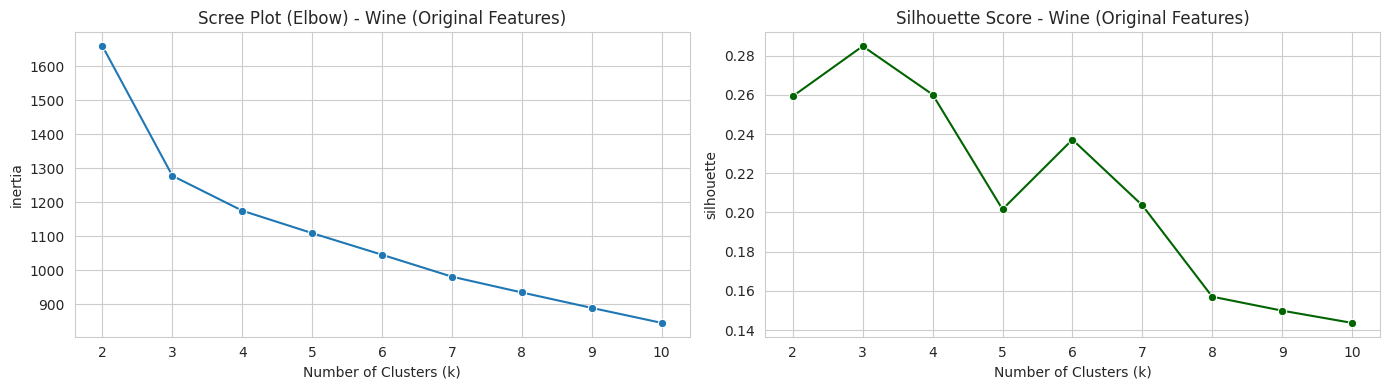

Selected k on original features: 3
K-Means Silhouette (original): 0.2849
Hierarchical Silhouette (original): 0.2774
ARI between K-Means and Hierarchical (original): 0.8530


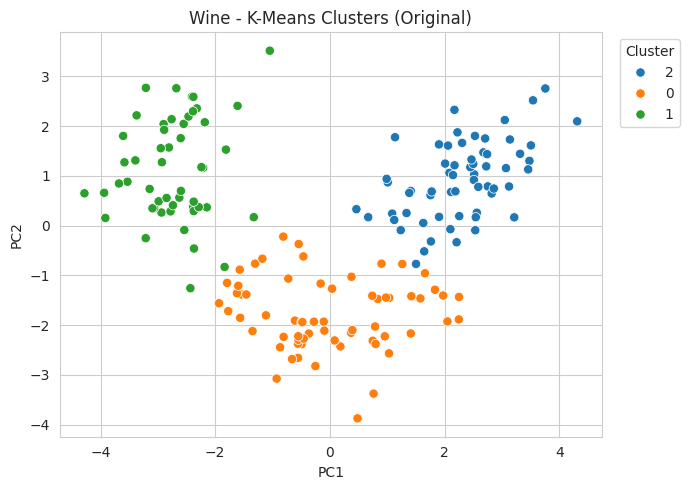

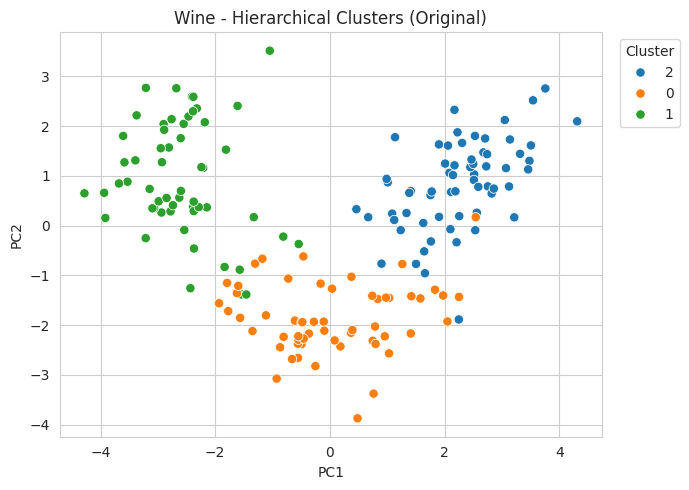

Cluster profile (original features, K-Means):


,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color
Cluster,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45


,PC1,PC2,PC3
0,3.316751,1.443463,-0.165739
1,2.209465,-0.333393,-2.026457
2,2.516740,1.031151,0.982819
3,3.757066,2.756372,-0.176192
4,1.008908,0.869831,2.026688


Explained variance ratio by 3 PCs: [0.362  0.1921 0.1112]
Cumulative explained variance (3 PCs): 0.6653


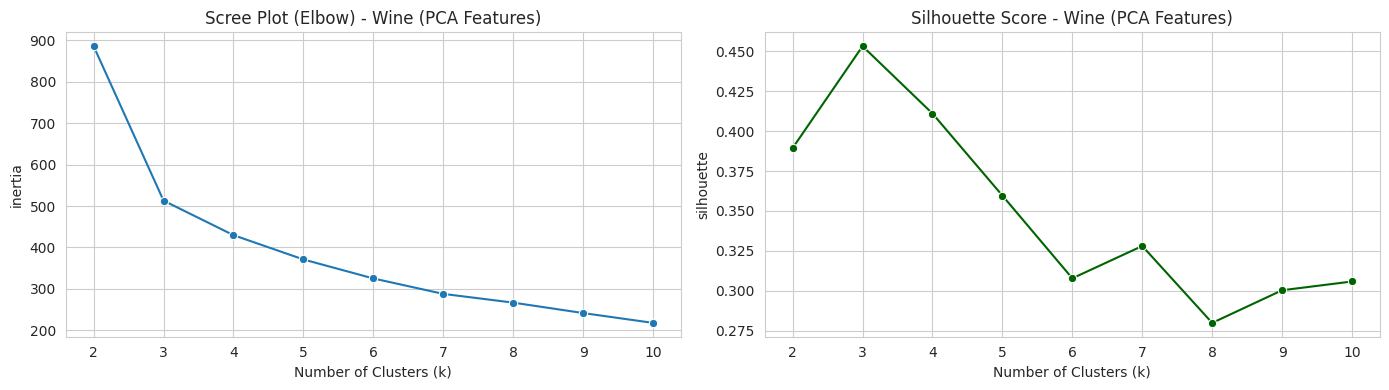

Selected k on PCA features: 3
K-Means Silhouette (PCA): 0.4532
Hierarchical Silhouette (PCA): 0.4459
ARI between K-Means and Hierarchical (PCA): 0.8678


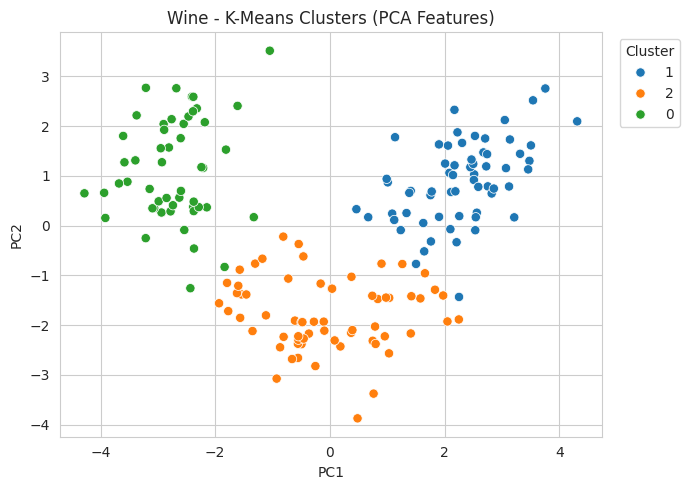

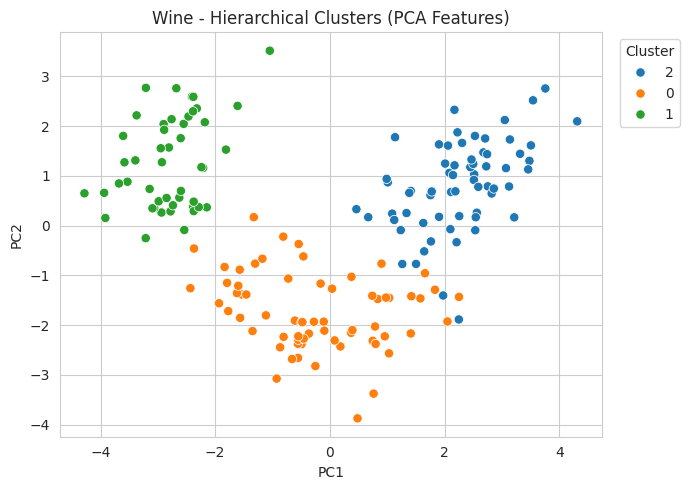

,Scenario,Selected_k,KMeans_Silhouette,Hierarchical_Silhouette,KM_vs_Hier_ARI,KMeans_BeforeAfter_ARI,Hier_BeforeAfter_ARI
0,Original,3,0.284859,0.277444,0.852984,0.981993,0.782899
1,PCA (3 PCs),3,0.453235,0.445949,0.867757,NaN,NaN


External validation using wine Type labels (higher is better):


,Method,ARI_vs_Type
0,KMeans Original,0.897495
1,KMeans PCA,0.880400
2,Hierarchical Original,0.789933
3,Hierarchical PCA,0.847519


In [3]:
# Using wine dataset for clustering comparison
wine_df = pd.read_excel("wine.xlsx")
print("Wine dataset shape:", wine_df.shape)
display(wine_df.head())

# Keep class column for external comparison only
wine_reference = wine_df["Type"].copy() if "Type" in wine_df.columns else None
wine_features_df, X_wine = preprocess_numeric(wine_df, drop_cols=["Type"])

# Original feature space clustering
wine_metrics_orig, wine_k_orig = evaluate_kmeans_range(X_wine, k_min=2, k_max=10)
plot_scree_and_silhouette(wine_metrics_orig, "Wine (Original Features)")

wine_k_labels_orig, wine_h_labels_orig, wine_k_sil_orig, wine_h_sil_orig, wine_internal_ari_orig = run_clustering(X_wine, wine_k_orig)
print(f"Selected k on original features: {wine_k_orig}")
print(f"K-Means Silhouette (original): {wine_k_sil_orig:.4f}")
print(f"Hierarchical Silhouette (original): {wine_h_sil_orig:.4f}")
print(f"ARI between K-Means and Hierarchical (original): {wine_internal_ari_orig:.4f}")

plot_cluster_projection(X_wine, wine_k_labels_orig, "Wine - K-Means Clusters (Original)")
plot_cluster_projection(X_wine, wine_h_labels_orig, "Wine - Hierarchical Clusters (Original)")

print("Cluster profile (original features, K-Means):")
display(cluster_profile(wine_features_df, wine_k_labels_orig))

# PCA transformation to first 3 components
pca_wine = PCA(n_components=3, random_state=RANDOM_STATE)
X_wine_pca = pca_wine.fit_transform(X_wine)
wine_pca_df = pd.DataFrame(X_wine_pca, columns=["PC1", "PC2", "PC3"])

display(wine_pca_df.head())
print("Explained variance ratio by 3 PCs:", np.round(pca_wine.explained_variance_ratio_, 4))
print("Cumulative explained variance (3 PCs):", round(pca_wine.explained_variance_ratio_.sum(), 4))

# Clustering on PCA feature space
wine_metrics_pca, wine_k_pca = evaluate_kmeans_range(X_wine_pca, k_min=2, k_max=10)
plot_scree_and_silhouette(wine_metrics_pca, "Wine (PCA Features)")

wine_k_labels_pca, wine_h_labels_pca, wine_k_sil_pca, wine_h_sil_pca, wine_internal_ari_pca = run_clustering(X_wine_pca, wine_k_pca)
print(f"Selected k on PCA features: {wine_k_pca}")
print(f"K-Means Silhouette (PCA): {wine_k_sil_pca:.4f}")
print(f"Hierarchical Silhouette (PCA): {wine_h_sil_pca:.4f}")
print(f"ARI between K-Means and Hierarchical (PCA): {wine_internal_ari_pca:.4f}")

plot_cluster_projection(X_wine_pca, wine_k_labels_pca, "Wine - K-Means Clusters (PCA Features)")
plot_cluster_projection(X_wine_pca, wine_h_labels_pca, "Wine - Hierarchical Clusters (PCA Features)")

# Before vs after PCA comparison metrics
wine_comparison = pd.DataFrame({
    "Scenario": ["Original", "PCA (3 PCs)"],
    "Selected_k": [wine_k_orig, wine_k_pca],
    "KMeans_Silhouette": [wine_k_sil_orig, wine_k_sil_pca],
    "Hierarchical_Silhouette": [wine_h_sil_orig, wine_h_sil_pca],
    "KM_vs_Hier_ARI": [wine_internal_ari_orig, wine_internal_ari_pca],
})

# Agreement of each method before vs after PCA
wine_comparison["KMeans_BeforeAfter_ARI"] = [adjusted_rand_score(wine_k_labels_orig, wine_k_labels_pca), np.nan]
wine_comparison["Hier_BeforeAfter_ARI"] = [adjusted_rand_score(wine_h_labels_orig, wine_h_labels_pca), np.nan]

display(wine_comparison)

if wine_reference is not None:
    # Optional external check against known wine class labels
    ref_ari = pd.DataFrame({
        "Method": ["KMeans Original", "KMeans PCA", "Hierarchical Original", "Hierarchical PCA"],
        "ARI_vs_Type": [
            adjusted_rand_score(wine_reference, wine_k_labels_orig),
            adjusted_rand_score(wine_reference, wine_k_labels_pca),
            adjusted_rand_score(wine_reference, wine_h_labels_orig),
            adjusted_rand_score(wine_reference, wine_h_labels_pca),
        ],
    })
    print("External validation using wine Type labels (higher is better):")
    display(ref_ari)

### Problem 1 Insights

- Compare silhouette scores before and after PCA to evaluate compactness and separation.
- Compare ARI between K-Means and Hierarchical to check cluster-structure consistency.
- If selected k and silhouette remain similar, PCA preserved essential structure while reducing dimensionality.
- If PCA improves silhouette, it likely removed noise/redundancy and made cluster boundaries clearer.

## Problem Statement 2: Pharmaceutical Dataset Analysis

Using heart disease data as the pharmaceutical patient dataset, perform clustering before and after PCA and compare patient segments.

Heart disease dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


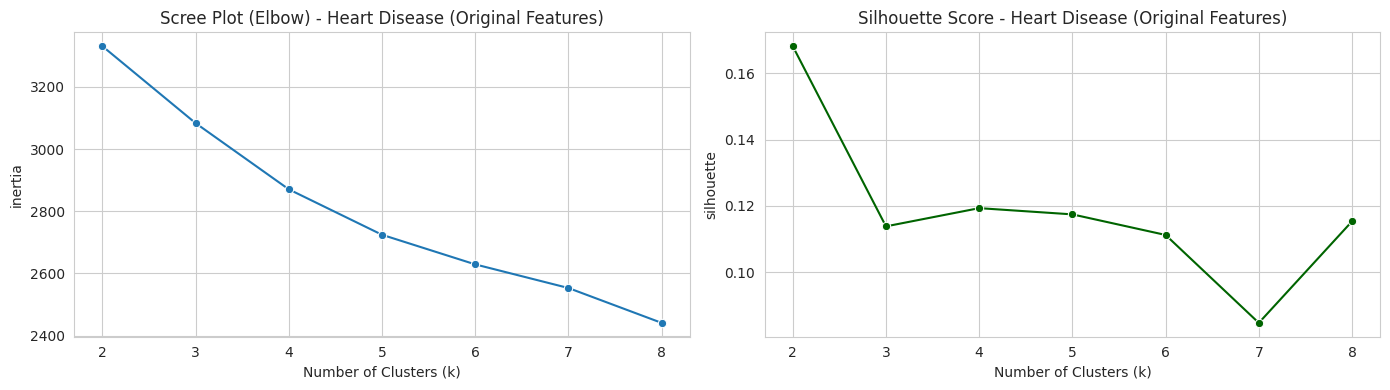

Selected k on original features: 2
K-Means Silhouette (original): 0.1682
Hierarchical Silhouette (original): 0.1325
ARI between K-Means and Hierarchical (original): 0.5256


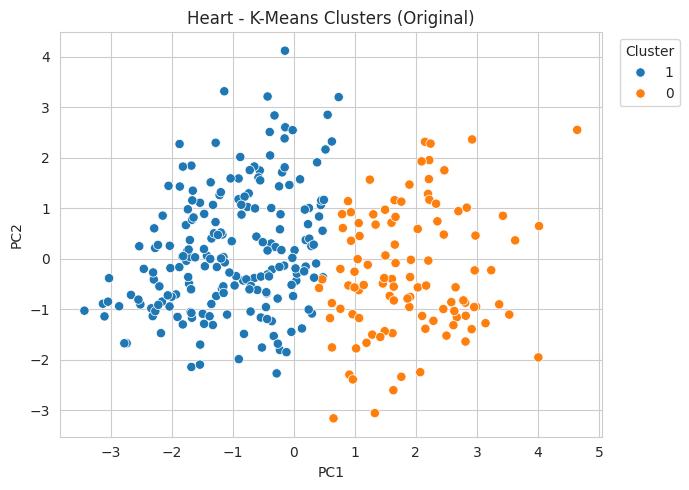

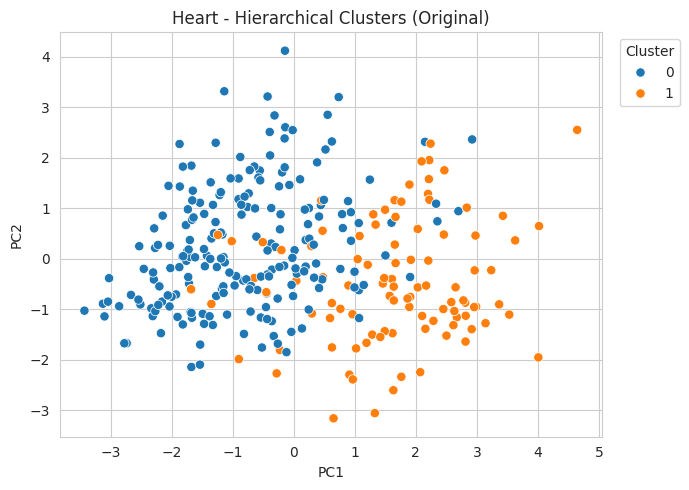

Cluster profile (original features, K-Means):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak
Cluster,,,,,,,,,,
0,58.49,0.76,0.25,135.81,252.34,0.17,0.47,129.73,0.71,1.90
1,52.18,0.64,1.35,129.40,243.04,0.14,0.56,160.21,0.12,0.58


,PC1,PC2,PC3
0,0.624111,2.321270,2.474673
1,-0.455988,-0.957351,1.139595
2,-1.828805,0.042885,-0.452229
3,-1.716006,-0.495337,0.030631
4,-0.371356,0.301156,-2.841069


Explained variance ratio by 3 PCs: [0.2125 0.1182 0.0941]
Cumulative explained variance (3 PCs): 0.4248


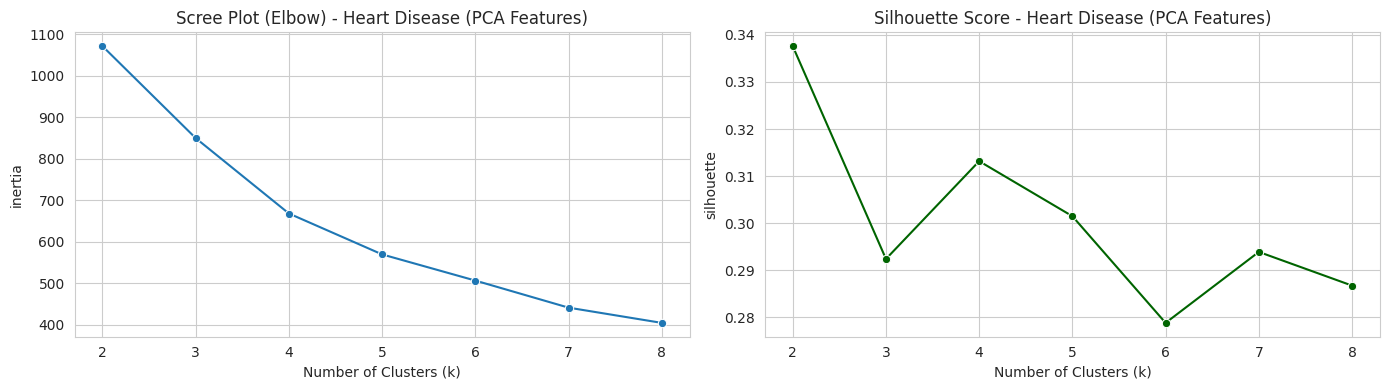

Selected k on PCA features: 2
K-Means Silhouette (PCA): 0.3376
Hierarchical Silhouette (PCA): 0.2897
ARI between K-Means and Hierarchical (PCA): 0.5690


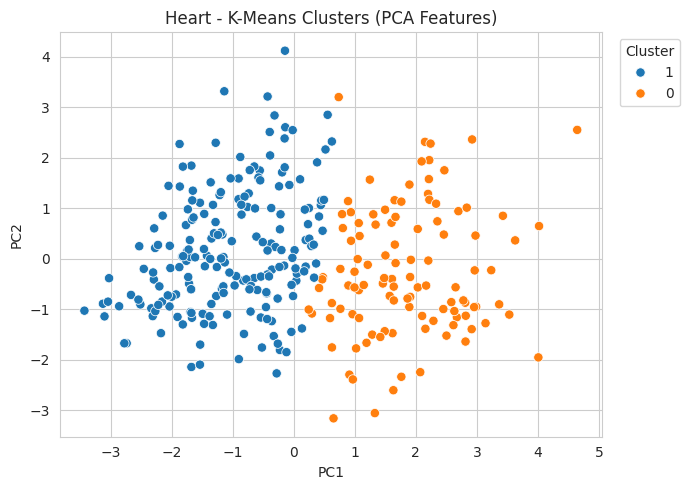

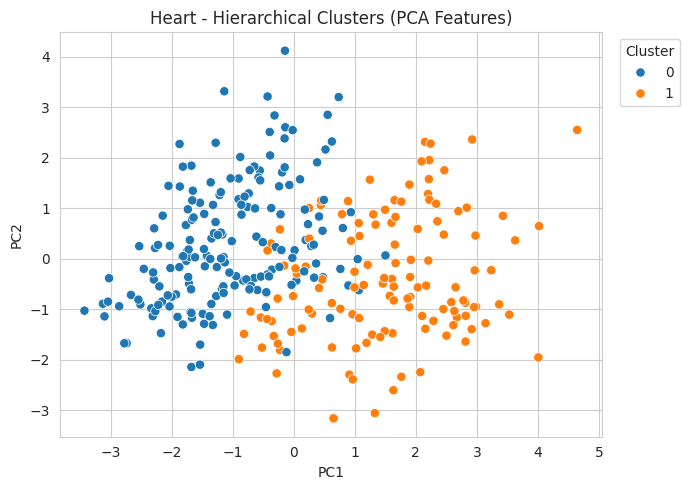

,Scenario,Selected_k,KMeans_Silhouette,Hierarchical_Silhouette,KM_vs_Hier_ARI,KMeans_BeforeAfter_ARI,Hier_BeforeAfter_ARI
0,Original,2,0.168233,0.132532,0.525562,0.947356,0.377077
1,PCA (3 PCs),2,0.337577,0.289678,0.568958,NaN,NaN


Age-group share by K-Means cluster (Original):


age,<=35,36-45,46-55,56-65,65+
row_0,,,,,
0,0.01,0.076,0.200,0.543,0.171
1,0.03,0.247,0.338,0.308,0.076


Age-group share by K-Means cluster (PCA):


age,<=35,36-45,46-55,56-65,65+
row_0,,,,,
0,0.009,0.073,0.202,0.541,0.174
1,0.031,0.253,0.340,0.304,0.072


External validation using target label (reference only):


,Method,ARI_vs_target
0,KMeans Original,0.386796
1,KMeans PCA,0.370486
2,Hierarchical Original,0.245468
3,Hierarchical PCA,0.316162


In [4]:
heart_df = pd.read_excel("heart disease.xlsx")
print("Heart disease dataset shape:", heart_df.shape)
display(heart_df.head())

# Target kept for external validation only
heart_reference = heart_df["target"].copy() if "target" in heart_df.columns else None
heart_features_df, X_heart = preprocess_numeric(heart_df, drop_cols=["target"])

# Age group segmentation helper for interpretation
if "age" in heart_df.columns:
    bins = [0, 35, 45, 55, 65, 120]
    labels = ["<=35", "36-45", "46-55", "56-65", "65+"]
    age_groups = pd.cut(heart_df["age"], bins=bins, labels=labels, include_lowest=True)
else:
    age_groups = pd.Series(["Unknown"] * len(heart_df))

# Original clustering
heart_metrics_orig, heart_k_orig = evaluate_kmeans_range(X_heart, k_min=2, k_max=8)
plot_scree_and_silhouette(heart_metrics_orig, "Heart Disease (Original Features)")

heart_k_labels_orig, heart_h_labels_orig, heart_k_sil_orig, heart_h_sil_orig, heart_internal_ari_orig = run_clustering(X_heart, heart_k_orig)
print(f"Selected k on original features: {heart_k_orig}")
print(f"K-Means Silhouette (original): {heart_k_sil_orig:.4f}")
print(f"Hierarchical Silhouette (original): {heart_h_sil_orig:.4f}")
print(f"ARI between K-Means and Hierarchical (original): {heart_internal_ari_orig:.4f}")

plot_cluster_projection(X_heart, heart_k_labels_orig, "Heart - K-Means Clusters (Original)")
plot_cluster_projection(X_heart, heart_h_labels_orig, "Heart - Hierarchical Clusters (Original)")

print("Cluster profile (original features, K-Means):")
display(cluster_profile(heart_features_df, heart_k_labels_orig))

# PCA to first three components
pca_heart = PCA(n_components=3, random_state=RANDOM_STATE)
X_heart_pca = pca_heart.fit_transform(X_heart)
heart_pca_df = pd.DataFrame(X_heart_pca, columns=["PC1", "PC2", "PC3"])
display(heart_pca_df.head())
print("Explained variance ratio by 3 PCs:", np.round(pca_heart.explained_variance_ratio_, 4))
print("Cumulative explained variance (3 PCs):", round(pca_heart.explained_variance_ratio_.sum(), 4))

# Clustering on PCA dataset
heart_metrics_pca, heart_k_pca = evaluate_kmeans_range(X_heart_pca, k_min=2, k_max=8)
plot_scree_and_silhouette(heart_metrics_pca, "Heart Disease (PCA Features)")

heart_k_labels_pca, heart_h_labels_pca, heart_k_sil_pca, heart_h_sil_pca, heart_internal_ari_pca = run_clustering(X_heart_pca, heart_k_pca)
print(f"Selected k on PCA features: {heart_k_pca}")
print(f"K-Means Silhouette (PCA): {heart_k_sil_pca:.4f}")
print(f"Hierarchical Silhouette (PCA): {heart_h_sil_pca:.4f}")
print(f"ARI between K-Means and Hierarchical (PCA): {heart_internal_ari_pca:.4f}")

plot_cluster_projection(X_heart_pca, heart_k_labels_pca, "Heart - K-Means Clusters (PCA Features)")
plot_cluster_projection(X_heart_pca, heart_h_labels_pca, "Heart - Hierarchical Clusters (PCA Features)")

# Comparison report
heart_comparison = pd.DataFrame({
    "Scenario": ["Original", "PCA (3 PCs)"],
    "Selected_k": [heart_k_orig, heart_k_pca],
    "KMeans_Silhouette": [heart_k_sil_orig, heart_k_sil_pca],
    "Hierarchical_Silhouette": [heart_h_sil_orig, heart_h_sil_pca],
    "KM_vs_Hier_ARI": [heart_internal_ari_orig, heart_internal_ari_pca],
})
heart_comparison["KMeans_BeforeAfter_ARI"] = [adjusted_rand_score(heart_k_labels_orig, heart_k_labels_pca), np.nan]
heart_comparison["Hier_BeforeAfter_ARI"] = [adjusted_rand_score(heart_h_labels_orig, heart_h_labels_pca), np.nan]
display(heart_comparison)

# Age-group distribution in K-Means segments (before and after PCA)
age_seg_before = pd.crosstab(heart_k_labels_orig, age_groups, normalize="index").round(3)
age_seg_after = pd.crosstab(heart_k_labels_pca, age_groups, normalize="index").round(3)
print("Age-group share by K-Means cluster (Original):")
display(age_seg_before)
print("Age-group share by K-Means cluster (PCA):")
display(age_seg_after)

if heart_reference is not None:
    ext_eval = pd.DataFrame({
        "Method": ["KMeans Original", "KMeans PCA", "Hierarchical Original", "Hierarchical PCA"],
        "ARI_vs_target": [
            adjusted_rand_score(heart_reference, heart_k_labels_orig),
            adjusted_rand_score(heart_reference, heart_k_labels_pca),
            adjusted_rand_score(heart_reference, heart_h_labels_orig),
            adjusted_rand_score(heart_reference, heart_h_labels_pca),
        ]
    })
    print("External validation using target label (reference only):")
    display(ext_eval)

### Problem 2 Analytical Report

- PCA performance impact: compare silhouette values before and after PCA to see whether lower-dimensional representation improves compactness/separation.
- Cluster formation differences: compare selected k, ARI between methods, and before-vs-after ARI values.
- Patient segments: inspect age-group composition and cluster mean profiles to identify low-risk vs high-risk patterns.

### Suggested Improvements

1. Tune feature engineering: add clinically meaningful interactions (for example age x cholesterol).
2. Optimize clustering hyperparameters: test alternative linkages/metrics and broader k range.
3. Use robust scaling/outlier handling for skewed biomedical variables.
4. Validate with multiple internal metrics (Davies-Bouldin, Calinski-Harabasz) and stability checks (bootstrap runs).
5. Consider non-linear reduction (UMAP/t-SNE for visualization) and Gaussian Mixture clustering for overlapping patient groups.

## Final Conclusion

- Both problem statements now include clustering before and after PCA with first 3 principal components.
- K-Means cluster count is guided by the scree (elbow) and silhouette trend.
- Comparative metrics and visualizations enable direct evaluation of structural similarity before vs after PCA.